# Assignment 4: Regularization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty to mean squared error prevents overfitting and prevents large coefficients from dominating the model. This simplifies the model so it can generalize better to new data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization increases bias by simplifying the model, but it reduces variance by preventing overfitting. This trade-off often leads to improved performance on unseen data.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge shrinks the coefficients but never makes them exactly zero, whereas LASSO can shrink irrelevant feature coefficients all the way to zero. As a result, LASSO performs feature selection and produces a simpler model, while Ridge keeps all variables and is better when many features are relevant.

4. How do we typically scale variables for use in regularized regression? Why?

We standardize variables using z-scores, which makes the mean = 0 and the standard deviation = 1. This ensures that all features are on the same scale so that the penalty treats them fairly and larger scales do not dominate.

5. How is the penalty $\alpha$ typically selected?

Alpha is selected using cross validation, and we select the value that minimizes the validation error (MSE).

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

We do not include the penalty. The penalty is used to train the model, but cross-validation is meant to assess predictive performance on unseen data. Therefore, only the MSE is used to evaluate how well the model generalizes.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.


In [2]:
df=pd.read_csv('/content/undergrad_ml_assignments/data/cars_hw.csv')

In [3]:
Age=2026-df['Make_Year']
df['Age']=Age
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

X = df[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?


In [5]:
from sklearn.linear_model import LinearRegression
y=df['Price']
model = LinearRegression()
model.fit(X_scaled, y)
feature_names=poly.get_feature_names_out(['Mileage_Run','Age'])
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_})
print(coef_df)

             Feature   Coefficient
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05


The interaction between Mileage_Run and Age is about -1.67e+05, so the sign is negative. This means that when both mileage and age increase together, the car's predicted value decreases more strongly than if the features were isolated.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)


In [6]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [7]:
from sklearn.linear_model import LassoCV
alphas= np.logspace(1,3,20)
lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=42, max_iter=100000)
lasso_cv.fit(X_scaled, y)
print(lasso_cv.alpha_)

88.58667904100822


4. Plot the cross-validated MSE by $\alpha$.


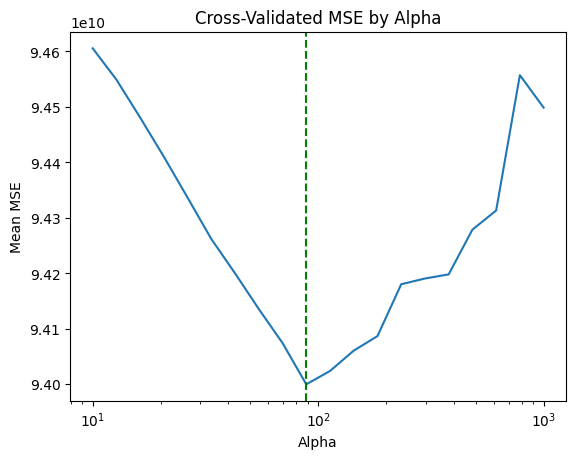

Optimal cost hyperparameter: 88.58667904100822


In [8]:
mean_mse = lasso_cv.mse_path_.mean(axis=1)
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse)
plt.axvline(x=lasso_cv.alpha_, color='green', linestyle='--')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean MSE')
plt.title('Cross-Validated MSE by Alpha')
plt.show()
print(f'Optimal cost hyperparameter: {lasso_cv.alpha_}')

5. Plot the coefficient paths by $\alpha$.


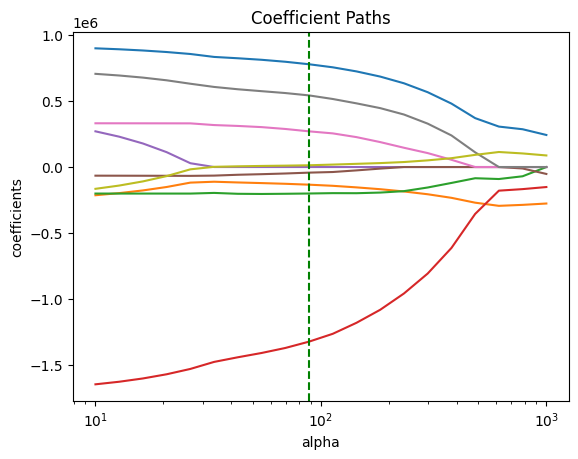

In [9]:
from sklearn.linear_model import Lasso
coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('Coefficient Paths')
plt.axvline(x=lasso_cv.alpha_, color='green', linestyle='--')
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?


In [10]:
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

for name, coef in zip(feature_names, lasso_cv.coef_):
    if coef != 0:
        print(name)

Mileage_Run
Age
Mileage_Run^2
Mileage_Run Age
Mileage_Run^3
Mileage_Run^2 Age
Mileage_Run Age^2
Age^3


In [11]:
num_zero = np.sum(lasso_cv.coef_ == 0)
total = len(lasso_cv.coef_)

print(num_zero / total)

0.1111111111111111


The selected features are those with non-zero coefficients. This includes Mileage_Run, age, and several interaction and polynomial terms. Age^2 is the only feature that was not selected, so 1/9, or 11%, of features were set to zero.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [12]:
for name, lin, las in zip(feature_names, model.coef_, lasso_cv.coef_):
    print(name, lin, las)

Mileage_Run 911774.8402226233 779076.2046509607
Age -248172.18553827342 -133953.43126016922
Mileage_Run^2 -207292.6283285836 -201563.40852789348
Mileage_Run Age -1671212.3563918793 -1322418.84628096
Age^2 350550.7198774649 0.0
Mileage_Run^3 -65144.89659917212 -42409.516408282616
Mileage_Run^2 Age 338819.4599153141 271506.19361202075
Mileage_Run Age^2 716781.5818001862 541543.1895758279
Age^3 -210037.88763612031 13742.203179995631


None of the coefficients increase in magnitude. They are all either decreased or set to zero. The only coefficient that changes sign is Age ^3, which goes from negative to positive.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [13]:
df=pd.read_csv('/content/undergrad_ml_assignments/data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [14]:
poly=PolynomialFeatures(degree=3, include_bias=False)
X_cont=df[['age','ejection_fraction','serum_creatinine']]
X_poly=poly.fit_transform(X_cont)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_poly)

In [15]:
poly_interact=PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)
X_cat=df[['anaemia','diabetes','high_blood_pressure','smoking']]
X_cat_interact=poly_interact.fit_transform(X_cat)
X_final = np.hstack([X_scaled, X_cat_interact])

In [16]:
print(X_final)

[[ 1.19294523 -1.53055953  0.49005699 ...  0.          0.
   0.        ]
 [-0.49127928 -0.00707675 -0.28455235 ...  0.          0.
   0.        ]
 [ 0.35083298 -1.53055953 -0.09090002 ...  0.          0.
   0.        ]
 ...
 [-1.33339153  1.85495776 -0.57503085 ...  0.          0.
   0.        ]
 [-1.33339153 -0.00707675  0.00592615 ...  0.          0.
   0.        ]
 [-0.9123354   0.58538877  0.19957848 ...  0.          0.
   0.        ]]



2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?


In [17]:
model = LinearRegression()
model.fit(X_final, df['DEATH_EVENT'])
model.coef_

array([ 1.54992821, -2.02537115, -0.73902663, -3.54799135, -0.86186031,
        1.68057013,  3.31793091,  2.60476657, -2.70308423,  1.88904043,
        1.0220272 , -0.67214115,  0.01757736, -1.58462005,  1.43324583,
       -1.25359396, -1.21927121,  1.21733534, -0.01490834, -0.04341968,
       -0.14947209, -0.07348019, -0.16820915,  0.13758466,  0.04070799,
        0.13928888,  0.28283055,  0.33792179,  0.21381703, -0.16799183,
       -0.22492963, -0.02999388, -0.31015604])

In [18]:
cat_features=poly_interact.get_feature_names_out(['anaemia','diabetes','high_blood_pressure','smoking'])
cont_features=poly.get_feature_names_out(['age','ejection_fraction','serum_creatinine'])
feature_names=np.concatenate([cat_features,cont_features])
for name, coef in zip(feature_names, model.coef_):
    print(name, coef)

anaemia 1.5499282143174289
diabetes -2.0253711459626436
high_blood_pressure -0.7390266263144294
smoking -3.5479913546212507
anaemia diabetes -0.8618603116515693
anaemia high_blood_pressure 1.6805701313624355
anaemia smoking 3.3179309135414186
diabetes high_blood_pressure 2.6047665663573367
diabetes smoking -2.7030842335373193
high_blood_pressure smoking 1.8890404293553769
anaemia diabetes high_blood_pressure 1.0220272046028533
anaemia diabetes smoking -0.6721411518731822
anaemia high_blood_pressure smoking 0.017577361900495747
diabetes high_blood_pressure smoking -1.5846200462001427
age 1.433245830559142
ejection_fraction -1.2535939553382658
serum_creatinine -1.2192712140991984
age^2 1.2173353410823662
age ejection_fraction -0.014908342693813623
age serum_creatinine -0.04341968321832935
ejection_fraction^2 -0.14947208879824894
ejection_fraction serum_creatinine -0.0734801944303668
serum_creatinine^2 -0.16820914756899405
age^3 0.13758466066296632
age^2 ejection_fraction 0.04070798973909

After applying linear regression, some signs of the coefficients do appear counterintuitive. For example, diabetes, smoking, and blood pressure have negative signs, even though they are generally associated with increased mortality risk. This occurs because the model includes polynomial and interaction terms, so the effect of these variables is spread across multiple features. The inclusion of interaction and higher-order terms allows the model to capture more complex, nonlinear relationships, which resolves the contradiction when considering the combined effect of all terms.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)


In [19]:
alphas= np.logspace(-5,5,30)
lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=42, max_iter=100000)
lasso_cv.fit(X_final, df['DEATH_EVENT'])
print(lasso_cv.alpha_)

0.005736152510448681


4. Plot the cross-validated MSE by $\alpha$.

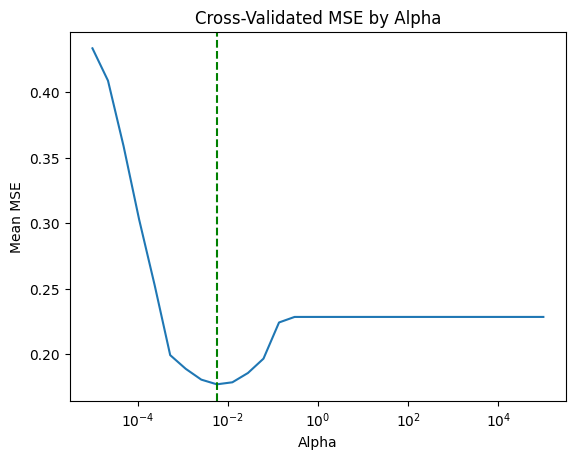

Optimal cost hyperparameter: 0.005736152510448681


In [20]:
mean_mse = lasso_cv.mse_path_.mean(axis=1)
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse)
plt.axvline(x=lasso_cv.alpha_, color='green', linestyle='--')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean MSE')
plt.title('Cross-Validated MSE by Alpha')
plt.show()
print(f'Optimal cost hyperparameter: {lasso_cv.alpha_}')

5. Plot the coefficient paths by $\alpha$.

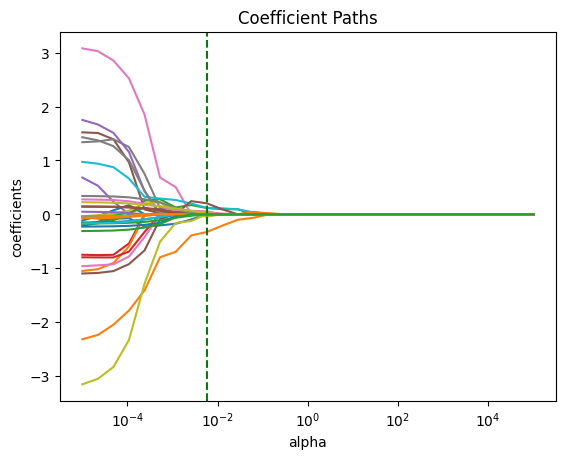

In [21]:
coefs=[]
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_final, df['DEATH_EVENT'])
    coefs.append(lasso.coef_)
coefs=np.array(coefs)
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('Coefficient Paths')
plt.axvline(x=lasso_cv.alpha_, color='green', linestyle='--')
plt.show()



6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [22]:
#features that were selected:
for name, coef in zip(feature_names, lasso_cv.coef_):
    if coef != 0:
        print(name)

diabetes
high_blood_pressure
high_blood_pressure smoking
ejection_fraction
serum_creatinine
age ejection_fraction
age serum_creatinine
ejection_fraction^2
ejection_fraction serum_creatinine
age ejection_fraction^2
age ejection_fraction serum_creatinine
age serum_creatinine^2


In [23]:
#proportion set to zero:
num_zero = np.sum(lasso_cv.coef_ == 0)
total = len(lasso_cv.coef_)

print(num_zero / total)

0.6363636363636364


In [24]:
for name, lin, las in zip(feature_names, model.coef_, lasso_cv.coef_):
    print(name, lin, las)

anaemia 1.5499282143174289 -0.0
diabetes -2.0253711459626436 -0.32965588260124196
high_blood_pressure -0.7390266263144294 0.116875130081409
smoking -3.5479913546212507 0.0
anaemia diabetes -0.8618603116515693 -0.0
anaemia high_blood_pressure 1.6805701313624355 0.0
anaemia smoking 3.3179309135414186 0.0
diabetes high_blood_pressure 2.6047665663573367 0.0
diabetes smoking -2.7030842335373193 -0.0
high_blood_pressure smoking 1.8890404293553769 0.11799179769122647
anaemia diabetes high_blood_pressure 1.0220272046028533 0.0
anaemia diabetes smoking -0.6721411518731822 0.0
anaemia high_blood_pressure smoking 0.017577361900495747 0.0
diabetes high_blood_pressure smoking -1.5846200462001427 0.0
age 1.433245830559142 -0.0
ejection_fraction -1.2535939553382658 0.2048216381616865
serum_creatinine -1.2192712140991984 0.032801101897877744
age^2 1.2173353410823662 -0.0
age ejection_fraction -0.014908342693813623 -0.04326608283025585
age serum_creatinine -0.04341968321832935 0.01417833634447046
eject

The features that LASSO actually selects include diabetes, high blood pressure, ejection fraction, and several other polynomial and interaction terms. Most of the interaction terms include age. Around 63.6% of the features are set to zero, indicating that they do not add predictive value. None of the coefficients increase in magnitude, but several coefficients chnage signs due to multicollinearity among predictors. Overall, the LASSO model is more stable and interpretable than linear regression. LASSO has a lower variance than linear regression, but it introduces some bias. This means that LASSO sacrafices some of the training fit to produce a simpler, more stable model that generalizes better.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.


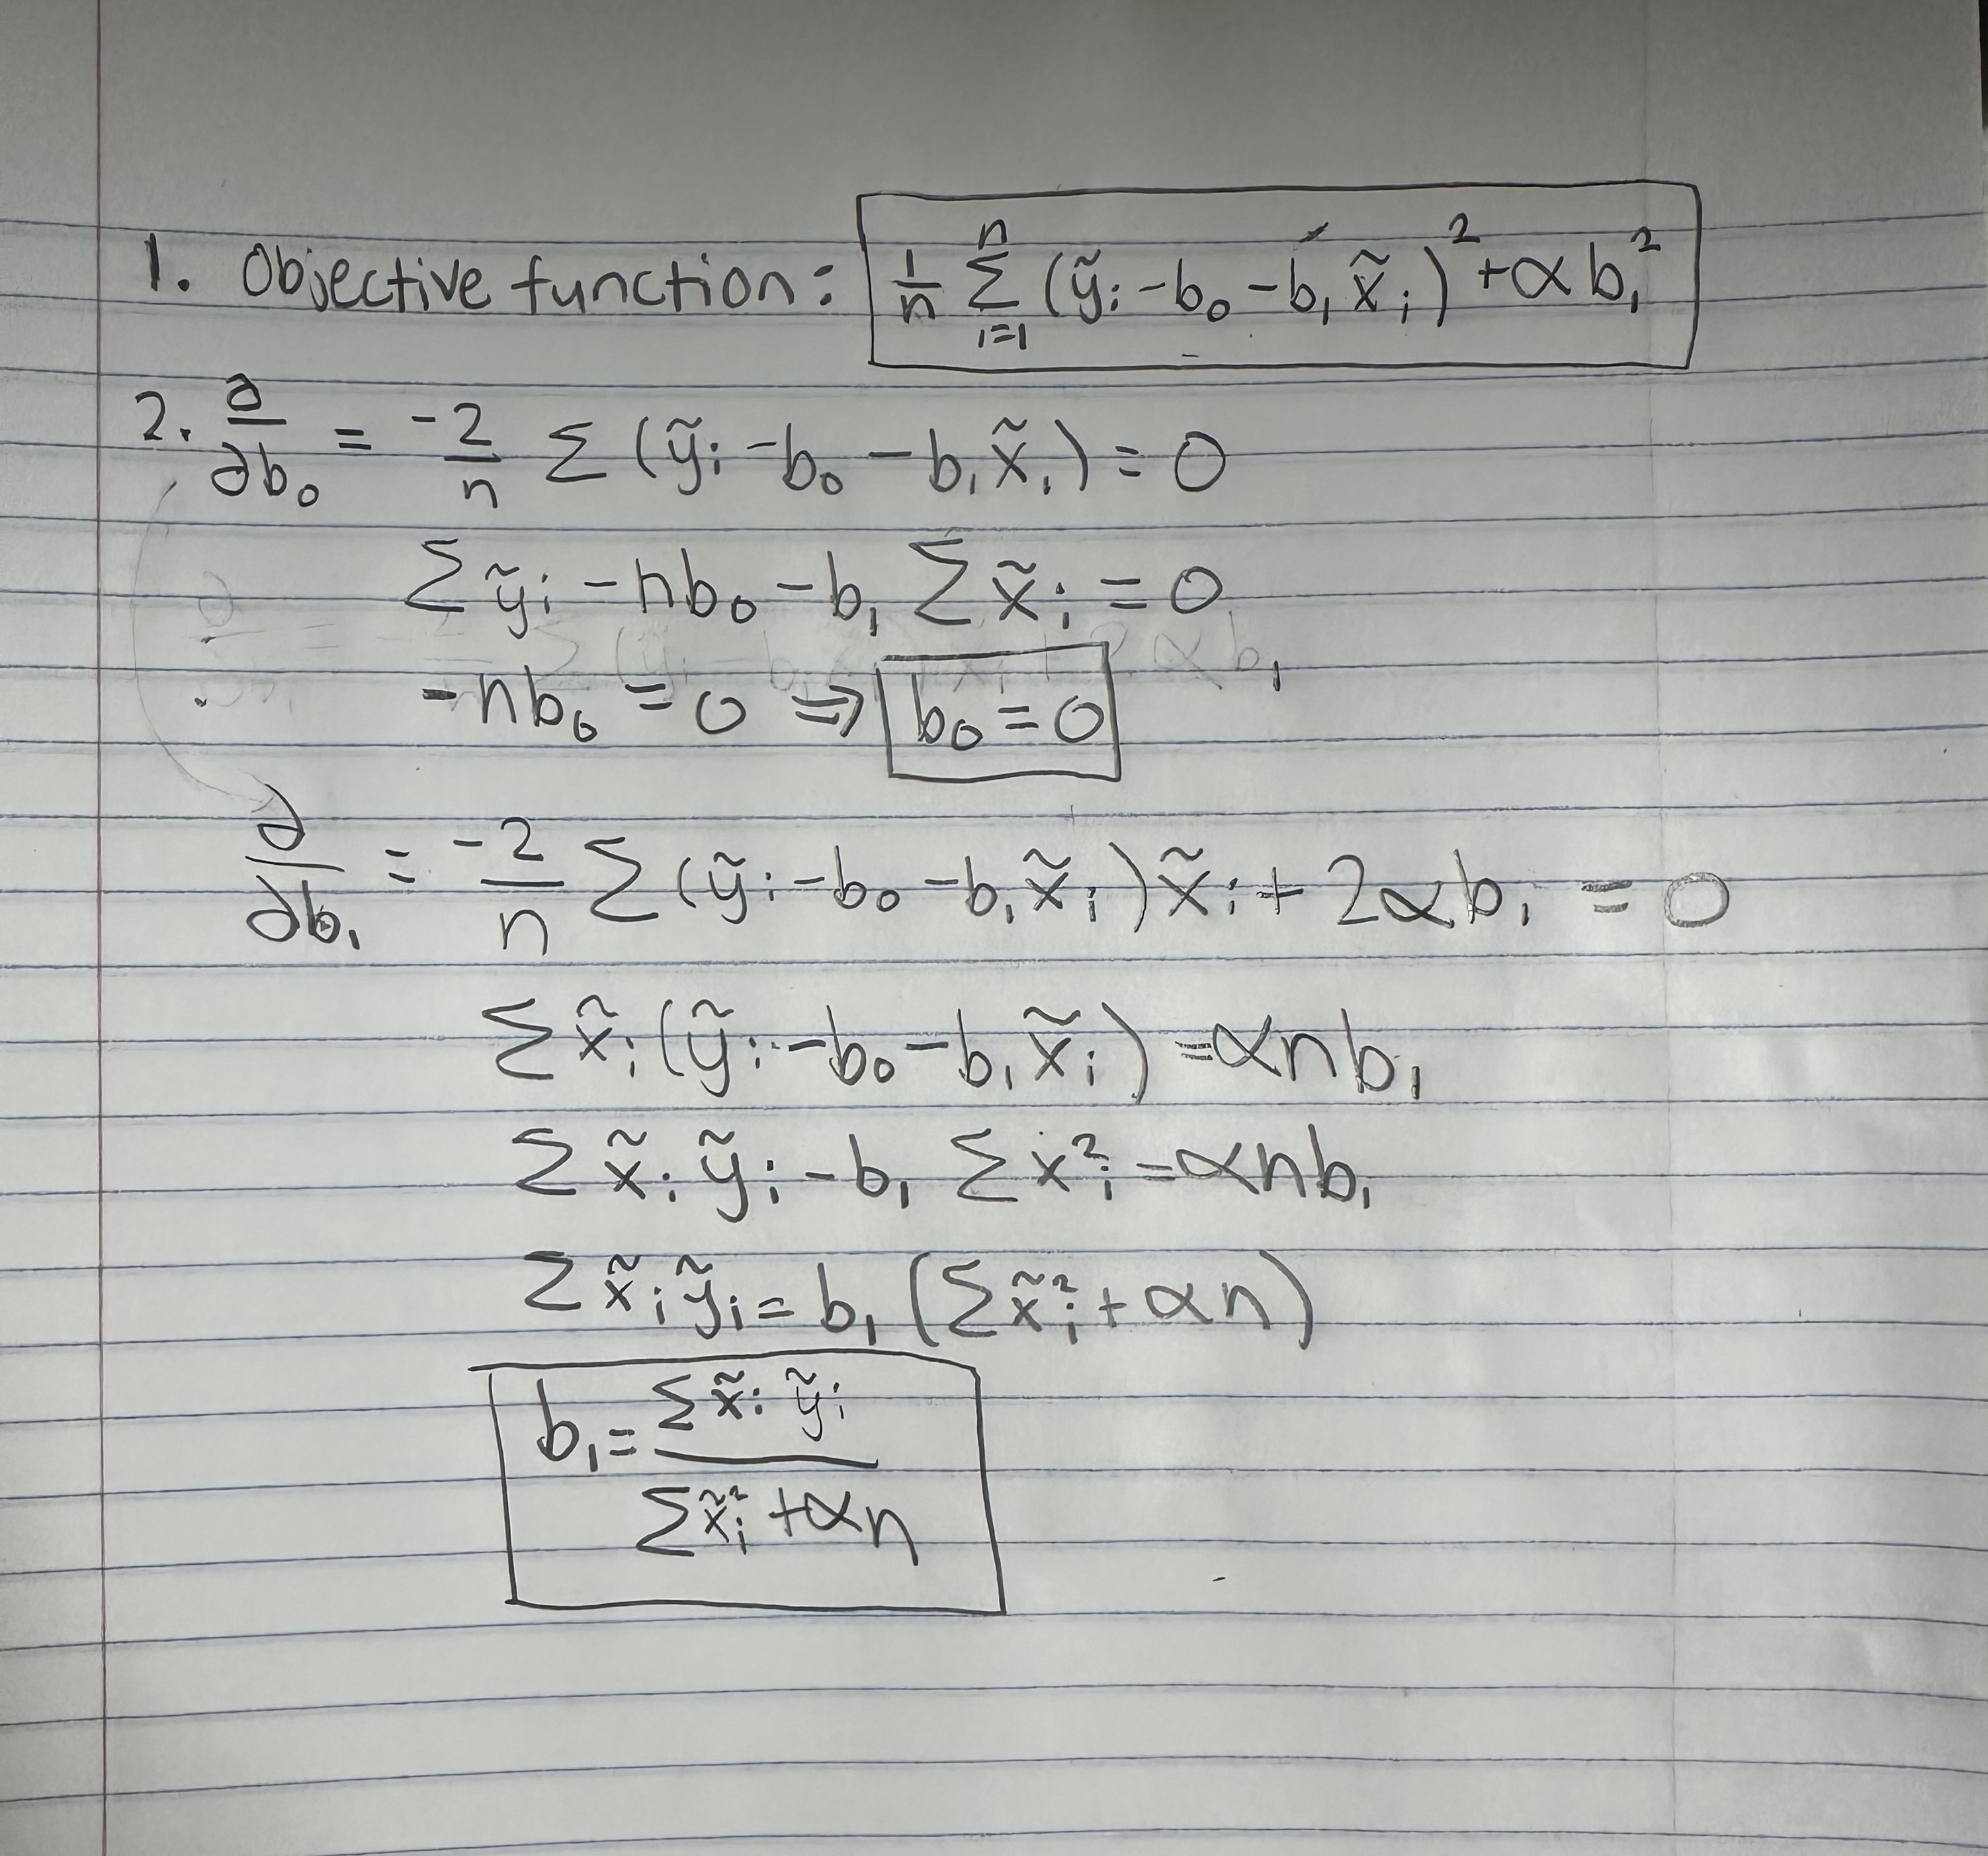

3. How does increasing $\alpha$ change the slope coefficient?

As alpha increases, the denominator gets bigger, so the slope coefficient, b1, gets smaller.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

If we use the LASSO penalty, we use the absolute value, which has a sharp corner at zero. Since the derivative is not defined at b1=0, we can't just take the derivative and set it to zero like we usually do. Instead, we have to consider cases when it is optimal for b1 to equal zero. This happens when the relationship between x and y is small relative to the penalty, meaning the model prefers to set the coefficient to zero rather than keep a small, less useful effect.